<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem011b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Molecule               Transition    Type  Peak Wavelength (nm)  \
0      H₂O      (symmetric stretch)      IR                  2700   
1      CO₂     (asymmetric stretch)      IR                  2350   
2      NH₃     (umbrella inversion)      IR                   950   
3       HF  (electronic excitation)  UV/Vis                   185   
4  Benzene                 (π → π*)  UV/Vis                   254   
5   Ethene                 (π → π*)  UV/Vis                   180   

   Absorption Intensity  
0                  0.68  
1                  0.57  
2                  0.53  
3                  0.89  
4                  0.86  
5                  0.78  


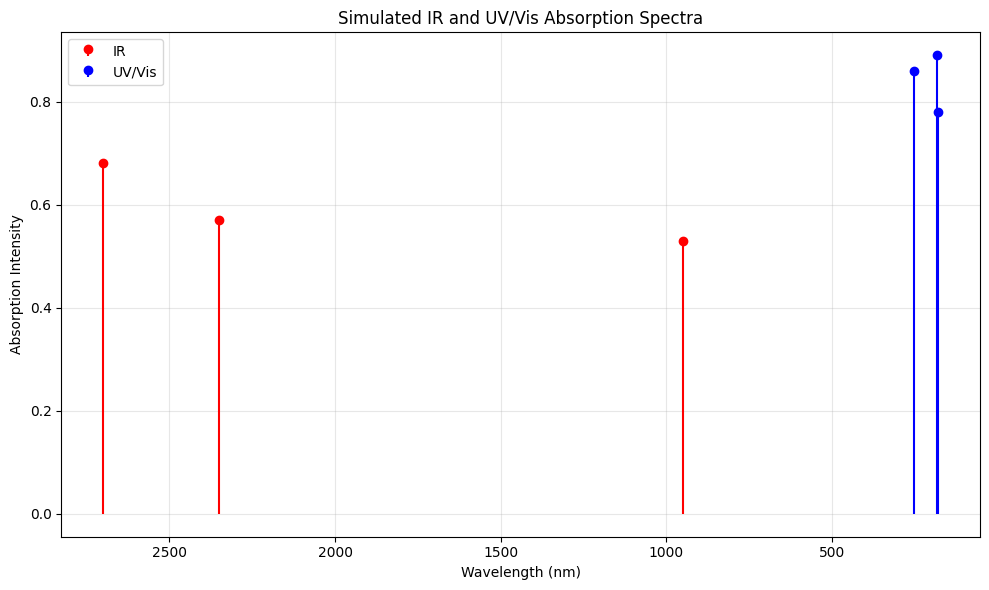

In [2]:
# Chem011B: IR and UV/Vis Spectral Profiles via Curvature Excitation

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define transitions with curvature shifts and peak wavelengths
transitions = {
    "H₂O (symmetric stretch)": {"type": "IR", "wavelength": 2700, "curvature_shift": 1.66},
    "CO₂ (asymmetric stretch)": {"type": "IR", "wavelength": 2350, "curvature_shift": 1.30},
    "NH₃ (umbrella inversion)": {"type": "IR", "wavelength": 950, "curvature_shift": 1.18},
    "HF (electronic excitation)": {"type": "UV/Vis", "wavelength": 185, "curvature_shift": 2.80},
    "Benzene (π → π*)": {"type": "UV/Vis", "wavelength": 254, "curvature_shift": 2.60},
    "Ethene (π → π*)": {"type": "UV/Vis", "wavelength": 180, "curvature_shift": 2.10}
}

# Absorption intensity model based on curvature shift
def absorption_intensity(shift):
    return round(np.tanh(shift / 2), 2)

# Simulate and collect results
results = []
for label, props in transitions.items():
    intensity = absorption_intensity(props["curvature_shift"])
    results.append({
        "Molecule": label.split(" ")[0],
        "Transition": label.split(" ", 1)[1],
        "Type": props["type"],
        "Peak Wavelength (nm)": props["wavelength"],
        "Absorption Intensity": intensity
    })

# Display results as a DataFrame
df = pd.DataFrame(results)
print(df)

# Plot spectra with corrected format strings
plt.figure(figsize=(10, 6))
colors = {"IR": "r", "UV/Vis": "b"}  # Use single-character color codes

for t in set(df["Type"]):
    subset = df[df["Type"] == t]
    plt.stem(subset["Peak Wavelength (nm)"], subset["Absorption Intensity"],
             linefmt=colors[t], markerfmt=colors[t] + "o", basefmt=" ", label=t)

plt.title("Simulated IR and UV/Vis Absorption Spectra")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorption Intensity")
plt.gca().invert_xaxis()  # Spectra usually show decreasing wavelength left to right
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
